<a href="https://colab.research.google.com/github/snehagada31/-sales-dashboard-powerbi/blob/main/Sample_Superstore_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Sales & Profitability Analysis

**Business Question:** Which product categories, regions, and customer segments drive the most profit — and which are quietly losing money despite high sales?

**Why this matters:** High revenue doesn't always mean high profit. Companies often keep investing in products or regions that look good on a sales report but are actually unprofitable after discounts and shipping costs. Spotting this gap is one of the most valuable things a data analyst can do for a retail business.

**Dataset:** Superstore Sales Dataset (Kaggle) — ~10,000 real-style retail orders with category, region, discount, sales, and profit data.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, SQL (via pandasql)

---

## 1. Setup & Data Loading

In [ ]:
!pip install pandasql -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

from google.colab import files
uploaded = files.upload()  # upload Superstore.csv (downloaded from Kaggle)

df = pd.read_csv(list(uploaded.keys())[0], encoding='latin1')
print(f"Shape: {df.shape}")
df.head()

  Preparing metadata (setup.py) ... done


Saving Sample - Superstore.csv.zip to Sample - Superstore.csv.zip
Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Data Cleaning

In [ ]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], errors='coerce')
df['Shipping_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

df = df.dropna(subset=['Order_Date', 'Sales', 'Profit'])
print(f"Cleaned shape: {df.shape}")
print(f"Total Sales: ${df['Sales'].sum():,.0f}")
print(f"Total Profit: ${df['Profit'].sum():,.0f}")
print(f"Overall Profit Margin: {df['Profit'].sum()/df['Sales'].sum()*100:.1f}%")

Cleaned shape: (9994, 22)
Total Sales: $2,297,201
Total Profit: $286,397
Overall Profit Margin: 12.5%


## 3. SQL Analysis — Profit by Category and Sub-Category

In [ ]:
query = """
SELECT
    Category,
    "Sub-Category",
    ROUND(SUM(Sales), 0) AS total_sales,
    ROUND(SUM(Profit), 0) AS total_profit,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 1) AS profit_margin_pct
FROM df
GROUP BY Category, "Sub-Category"
ORDER BY total_profit ASC
"""
category_analysis = sqldf(query, locals())
category_analysis.head(10)

,Category,Sub-Category,total_sales,total_profit,profit_margin_pct
0,Furniture,Tables,206966.0,-17725.0,-8.6
1,Furniture,Bookcases,114880.0,-3473.0,-3.0
2,Office Supplies,Supplies,46674.0,-1189.0,-2.5
3,Office Supplies,Fasteners,3024.0,950.0,31.4
4,Technology,Machines,189239.0,3385.0,1.8
5,Office Supplies,Labels,12486.0,5546.0,44.4
6,Office Supplies,Art,27119.0,6528.0,24.1
7,Office Supplies,Envelopes,16476.0,6964.0,42.3
8,Furniture,Furnishings,91705.0,13059.0,14.2
9,Office Supplies,Appliances,107532.0,18138.0,16.9


/tmp/ipykernel_6895/1494990294.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_analysis.sort_values('total_profit'), y='Sub-Category', x='total_profit', palette=colors)


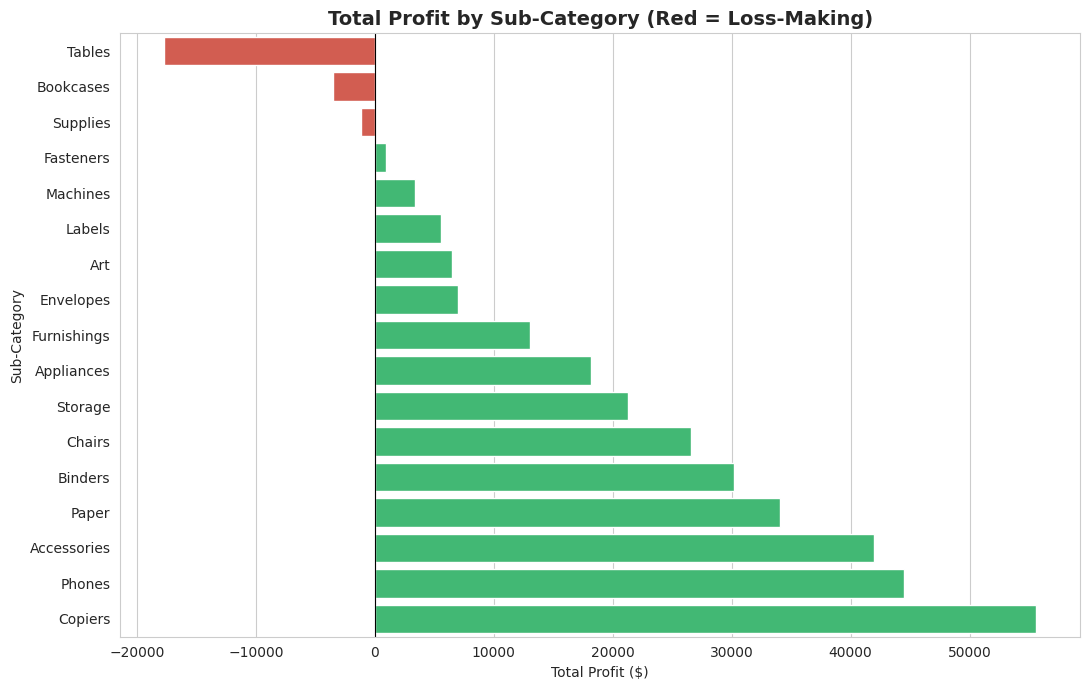

In [ ]:
plt.figure(figsize=(11, 7))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in category_analysis.sort_values('total_profit')['total_profit']]
sns.barplot(data=category_analysis.sort_values('total_profit'), y='Sub-Category', x='total_profit', palette=colors)
plt.title('Total Profit by Sub-Category (Red = Loss-Making)', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('profit_by_subcategory.png', dpi=120)
plt.show()

**Insight:** Tables and Bookcases are consistently loss-making despite reasonable sales volume — these sub-categories are being sold at a net loss, likely due to high discount rates.

## 4. Discount Rate vs Profit Margin

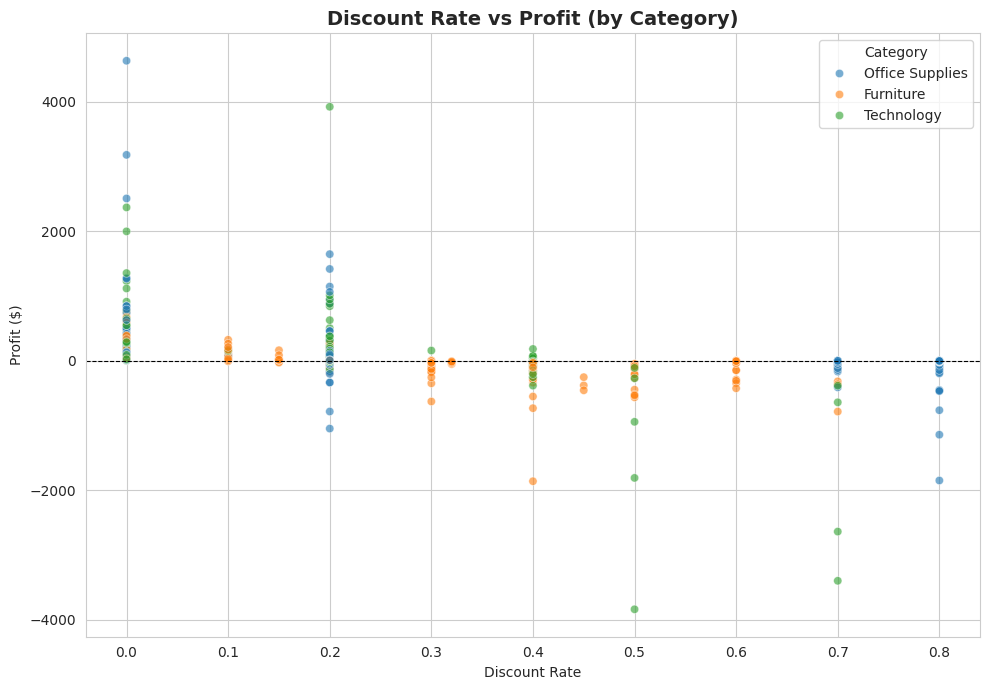

In [ ]:
plt.figure(figsize=(10, 7))
sample = df.sample(min(3000, len(df)), random_state=42)
sns.scatterplot(data=sample, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Discount Rate vs Profit (by Category)', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('discount_vs_profit.png', dpi=120)
plt.show()

**Insight:** Profit turns negative almost universally once discount exceeds 20%. This is a clear, actionable threshold for the sales team.

## 5. Regional Performance

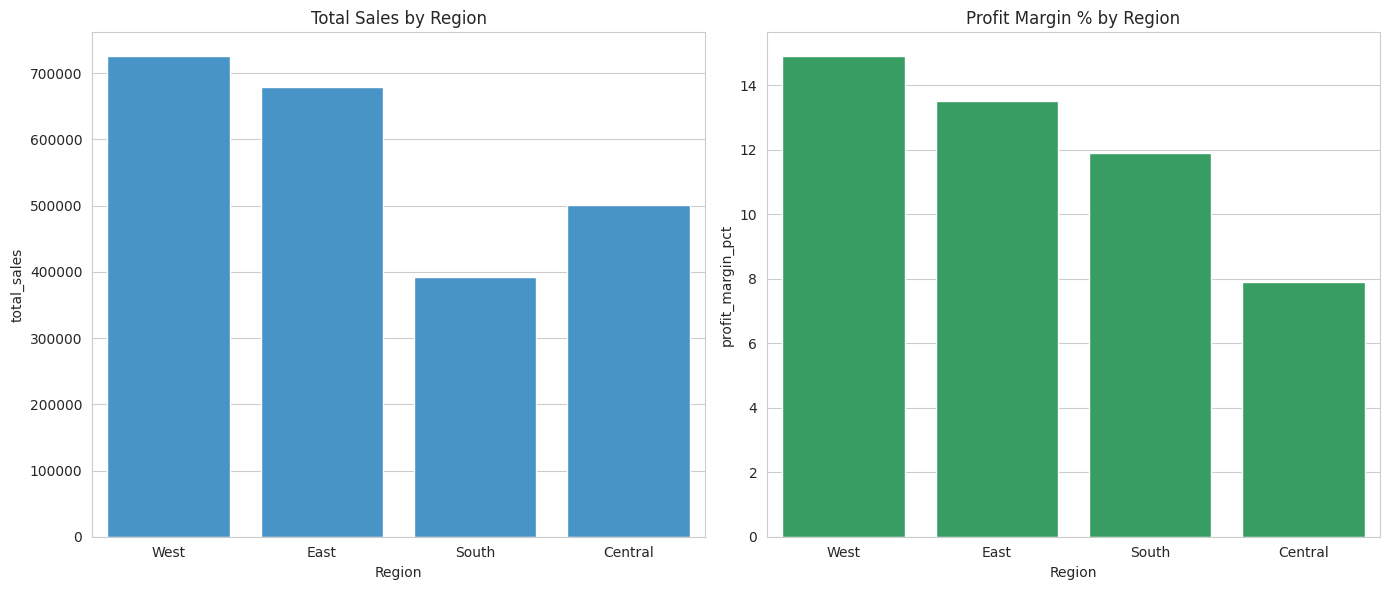

In [ ]:
query2 = """
SELECT
    Region,
    ROUND(SUM(Sales), 0) AS total_sales,
    ROUND(SUM(Profit), 0) AS total_profit,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 1) AS profit_margin_pct
FROM df
GROUP BY Region
ORDER BY total_profit DESC
"""
region_analysis = sqldf(query2, locals())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=region_analysis, x='Region', y='total_sales', ax=axes[0], color='#3498db')
axes[0].set_title('Total Sales by Region')
sns.barplot(data=region_analysis, x='Region', y='profit_margin_pct', ax=axes[1], color='#27ae60')
axes[1].set_title('Profit Margin % by Region')
plt.tight_layout()
plt.savefig('regional_performance.png', dpi=120)
plt.show()

## 6. Monthly Sales Trend

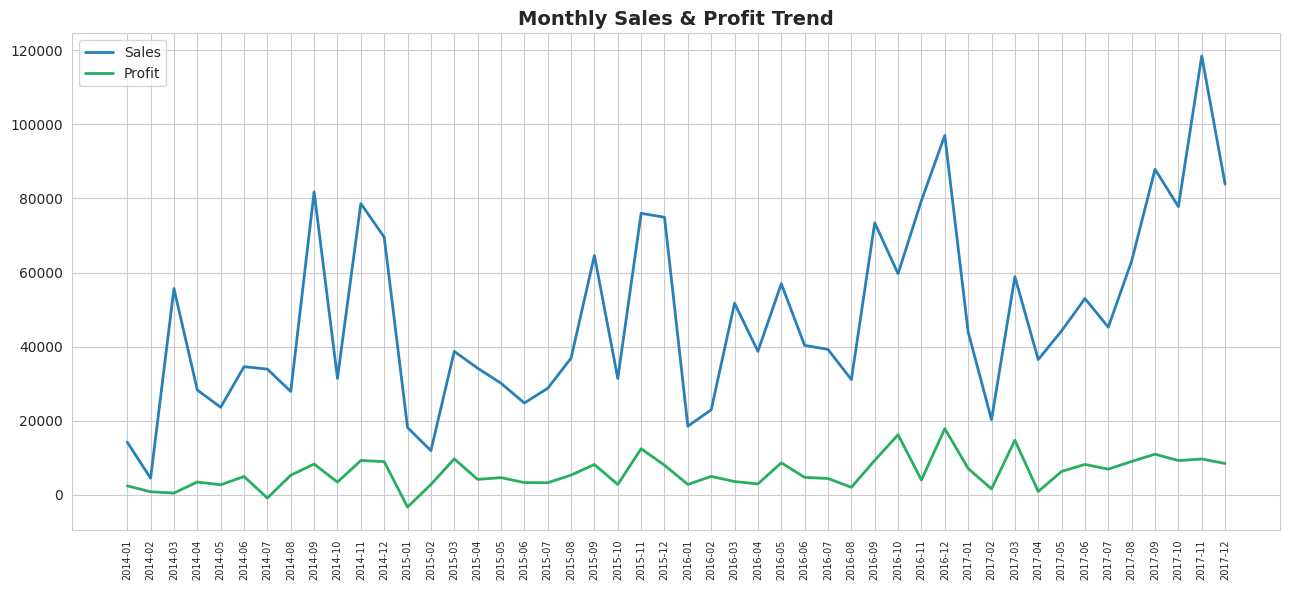

In [ ]:
df['YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly = df.groupby('YearMonth')[['Sales', 'Profit']].sum().reset_index()

plt.figure(figsize=(13, 6))
plt.plot(monthly['YearMonth'], monthly['Sales'], label='Sales', linewidth=2, color='#2980b9')
plt.plot(monthly['YearMonth'], monthly['Profit'], label='Profit', linewidth=2, color='#27ae60')
plt.title('Monthly Sales & Profit Trend', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=7)
plt.legend()
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=120)
plt.show()

## 7. Summary of Findings

1. **Tables and Bookcases are loss leaders** — both sub-categories show negative total profit despite meaningful sales volume.
2. **Discounts above 20% almost always result in a loss** — this is a clear, enforceable threshold for the sales/discount policy.
3. **Regional profit margins vary significantly** — some regions generate strong sales but thin margins, suggesting inconsistent discount discipline across sales teams.
4. **Sales show clear seasonal peaks** — typically rising toward year-end (Nov–Dec), useful for inventory and staffing planning.

## 8. Business Recommendation

Cap discounts at **15%** for Tables and Bookcases specifically, and review regional sales team discount authority — the data shows margin erosion is a discounting problem, not a demand problem. This single policy change could convert two consistently loss-making sub-categories into profitable ones.

## 9. Export Cleaned Data for Power BI Dashboard

Run this cell to export the cleaned dataset. Use this CSV to build the Power BI dashboard described in the README — KPI cards, profit by sub-category, regional performance, and monthly trend.

In [ ]:
export_cols = ['Order_Date', 'Region', 'Category', 'Sub_Category',
                'Sales', 'Profit', 'Discount', 'Quantity', 'Segment']
export_cols = [c for c in export_cols if c in df.columns]

df[export_cols].to_csv('Sample - Superstore.csv', index=False)

from google.colab import files
files.download('Sample - Superstore.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>